In [2]:
!pip install yfinance -q


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

## Downloading Dataset

In [6]:
stock = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
stock.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630630,72.389250,71.406659,71.563198,146322800
2020-01-06,72.201416,72.239950,70.503554,70.754021,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017838,73.318877,71.565621,71.565621,132079200


## Seperating Target/Label

In [7]:
stock["Target"] = stock["Close"].shift(-1)
stock = stock.dropna()

## Selecting Features for training

In [8]:
features = ["Open", "High", "Low", "Volume"]

X = stock[features]
y = stock["Target"]

## Train/Test Split

In [9]:
split = int(len(stock) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Model: Linear Regressor - train/inference

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

## Model: Random Forest - train/inference

In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

## Losses

In [12]:
lr_mse = mean_squared_error(y_test, lr_preds)
rf_mse = mean_squared_error(y_test, rf_preds)

print("Linear Regression MSE:", lr_mse)
print("Random Forest MSE:", rf_mse)

Linear Regression MSE: 4.936847730021543
Random Forest MSE: 107.06642891506755


## Figure

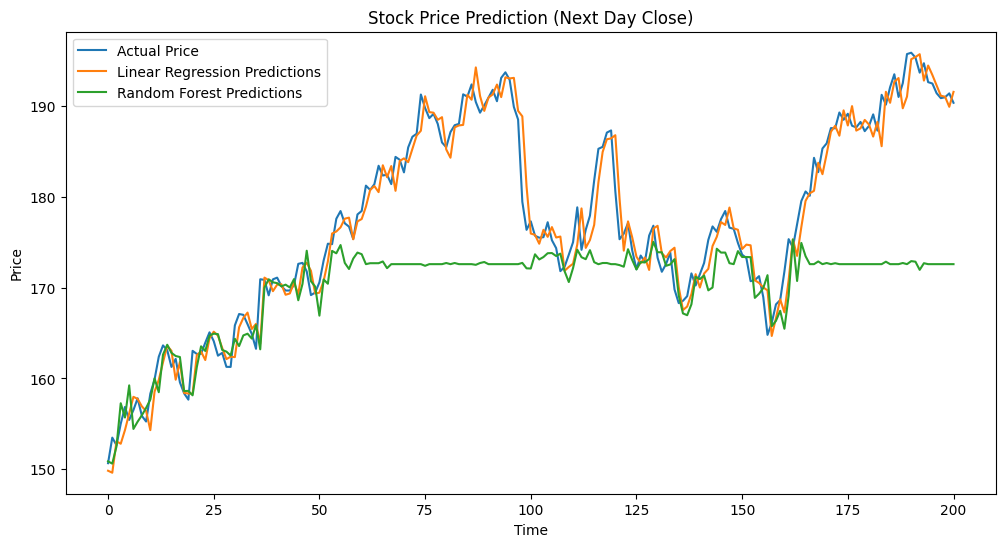

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual Price")
plt.plot(lr_preds, label="Linear Regression Predictions")
plt.plot(rf_preds, label="Random Forest Predictions")

plt.legend()
plt.title("Stock Price Prediction (Next Day Close)")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()

## Prediction

In [11]:
latest_data = X.tail(1)

lr_next = lr_model.predict(latest_data)[0]
rf_next = rf_model.predict(latest_data)[0]

print("Next Day Prediction (LR):", lr_next)
print("Next Day Prediction (RF):", rf_next)

Next Day Prediction (LR): 191.7546943059312
Next Day Prediction (RF): 172.7467855834961
